In [71]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [72]:
df = pd.read_csv('heart_disease_enriched.csv')
df.head()

,gender,age,hypertension,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,heart_disease,total_cholesterol,hdl_cholesterol,ldl_cholesterol,family_history,physical_activity_level,alcohol_intake
0,0,80.0,0,4,25.19,6.6,140,0,1,217.384995,44.380747,142.530952,1,moderate,none
1,0,54.0,0,0,27.32,6.6,80,0,0,195.160749,41.564369,132.036407,0,sedentary,moderate
2,1,28.0,0,4,27.32,5.7,158,0,0,222.669099,54.163599,144.305815,0,moderate,high
3,0,36.0,0,1,23.45,5.0,155,0,0,253.306045,45.818711,174.174821,0,moderate,none
4,1,76.0,1,1,20.14,4.8,155,0,1,191.804632,53.795672,116.734181,1,sedentary,none


In [73]:
df.isna().any()

,0
gender,False
age,False
hypertension,False
smoking_history,False
bmi,False
HbA1c_level,False
blood_glucose_level,False
diabetes,False
heart_disease,False
total_cholesterol,False


In [74]:
df.duplicated().any()

np.False_

In [75]:
df.shape

(192116, 15)

EDA

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns


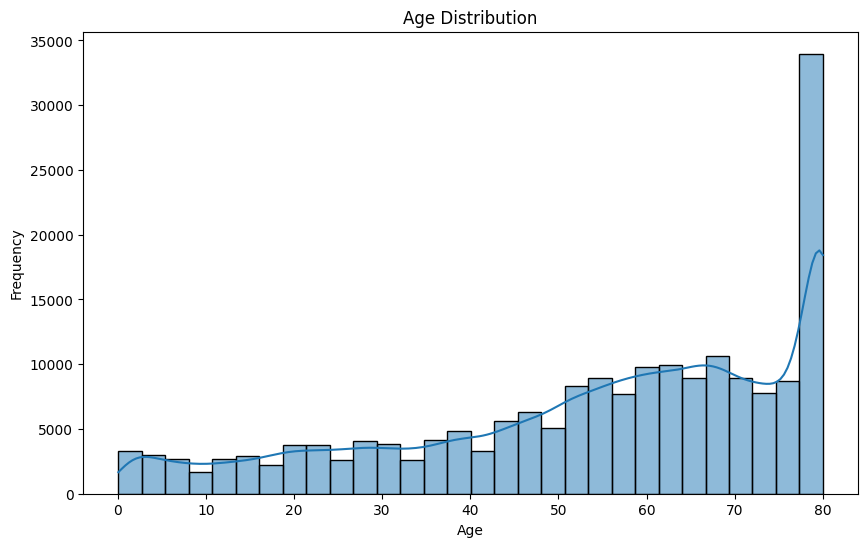

In [77]:
#age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='gender', ylabel='count'>

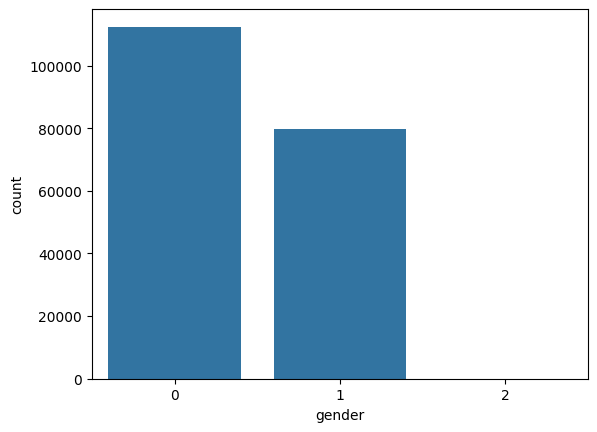

In [78]:
sns.countplot(data=df, x='gender')

In [79]:
df['heart_disease'].value_counts()

,count
heart_disease,
1,96058
0,96058


In [80]:
df.columns

df

,gender,age,hypertension,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,heart_disease,total_cholesterol,hdl_cholesterol,ldl_cholesterol,family_history,physical_activity_level,alcohol_intake
0,0,80.000000,0,4,25.190000,6.600000,140,0,1,217.384995,44.380747,142.530952,1,moderate,none
1,0,54.000000,0,0,27.320000,6.600000,80,0,0,195.160749,41.564369,132.036407,0,sedentary,moderate
2,1,28.000000,0,4,27.320000,5.700000,158,0,0,222.669099,54.163599,144.305815,0,moderate,high
3,0,36.000000,0,1,23.450000,5.000000,155,0,0,253.306045,45.818711,174.174821,0,moderate,none
4,1,76.000000,1,1,20.140000,4.800000,155,0,1,191.804632,53.795672,116.734181,1,sedentary,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192111,1,72.000000,0,4,27.125407,5.181862,155,0,1,186.669472,60.579105,101.435630,1,sedentary,none
192112,0,53.358479,0,1,20.213404,5.902836,140,0,1,237.241014,47.613138,158.630116,0,moderate,moderate
192113,1,70.000000,0,3,27.299468,4.783930,90,0,1,213.395901,47.397377,151.518015,0,sedentary,none
192114,0,80.000000,0,4,27.320000,5.721522,158,0,1,228.777431,45.538425,155.915847,0,sedentary,moderate


In [81]:
cat_col = ['physical_activity_level' , 'alcohol_intake']
for col in cat_col:
    df[col] = df[col].astype('category').cat.codes

In [82]:
df

,gender,age,hypertension,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,heart_disease,total_cholesterol,hdl_cholesterol,ldl_cholesterol,family_history,physical_activity_level,alcohol_intake
0,0,80.000000,0,4,25.190000,6.600000,140,0,1,217.384995,44.380747,142.530952,1,1,2
1,0,54.000000,0,0,27.320000,6.600000,80,0,0,195.160749,41.564369,132.036407,0,2,1
2,1,28.000000,0,4,27.320000,5.700000,158,0,0,222.669099,54.163599,144.305815,0,1,0
3,0,36.000000,0,1,23.450000,5.000000,155,0,0,253.306045,45.818711,174.174821,0,1,2
4,1,76.000000,1,1,20.140000,4.800000,155,0,1,191.804632,53.795672,116.734181,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192111,1,72.000000,0,4,27.125407,5.181862,155,0,1,186.669472,60.579105,101.435630,1,2,2
192112,0,53.358479,0,1,20.213404,5.902836,140,0,1,237.241014,47.613138,158.630116,0,1,1
192113,1,70.000000,0,3,27.299468,4.783930,90,0,1,213.395901,47.397377,151.518015,0,2,2
192114,0,80.000000,0,4,27.320000,5.721522,158,0,1,228.777431,45.538425,155.915847,0,2,1


In [83]:
x = df.drop(['heart_disease' , 'hdl_cholesterol' , 'ldl_cholesterol'], axis=1)
y = df['heart_disease']

In [84]:
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((153692, 12), (38424, 12), (153692,), (38424,))

In [86]:
std = StandardScaler()
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

Model Training


In [87]:
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=150,
    learning_rate=0.2,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42
)

In [88]:
xgb_clf.fit(X_train, y_train)

# Make predictions
y_pred = xgb_clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:30:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [89]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9424
ROC AUC Score: 0.9424

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     19158
           1       0.97      0.92      0.94     19266

    accuracy                           0.94     38424
   macro avg       0.94      0.94      0.94     38424
weighted avg       0.94      0.94      0.94     38424



Random Forest

In [90]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [91]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9241
ROC AUC Score: 0.9240

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     19158
           1       0.90      0.96      0.93     19266

    accuracy                           0.92     38424
   macro avg       0.93      0.92      0.92     38424
weighted avg       0.93      0.92      0.92     38424



### Hyperparameter Tuning for Random Forest Model



In [111]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [112]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')


In [ ]:
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [ ]:
# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score found: ", grid_search.best_score_)


In [ ]:
# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the best model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_tuned)

print(f"\nAccuracy with tuned Random Forest: {accuracy_tuned:.4f}")
print(f"ROC AUC Score with tuned Random Forest: {roc_auc_tuned:.4f}")
print("\nClassification Report with tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned))


In [103]:
import joblib

joblib.dump(rf_model, 'heart_disease_rf_model.pkl')

['heart_disease_rf_model.pkl']

In [104]:
import joblib

joblib.dump(std, 'scaler.pkl')
print("StandardScaler exported as 'scaler.pkl'")

StandardScaler exported as 'scaler.pkl'


In [105]:
import joblib
import pandas as pd
import numpy as np

# Load the exported model and scaler
loaded_rf_model = joblib.load('heart_disease_rf_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


Now, let's create a sample of random feature values for prediction. It's crucial that these values mimic the structure and ranges of the training data. The original features used for training were:

`'gender', 'age', 'hypertension', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'total_cholesterol', 'family_history', 'physical_activity_level', 'alcohol_intake'`

In [106]:
# Create a DataFrame with random values for each feature
# Ensure the column names and order match the training data 'x'
random_data = pd.DataFrame({
    'gender': np.random.choice([0, 1], size=1),
    'age': np.random.uniform(18, 90, size=1),
    'hypertension': np.random.choice([0, 1], size=1),
    'smoking_history': np.random.randint(0, 5, size=1), # Assuming 0-4 categories
    'bmi': np.random.uniform(15, 40, size=1),
    'HbA1c_level': np.random.uniform(4.0, 9.0, size=1),
    'blood_glucose_level': np.random.uniform(70, 200, size=1),
    'diabetes': np.random.choice([0, 1], size=1),
    'total_cholesterol': np.random.uniform(150, 300, size=1),
    'family_history': np.random.choice([0, 1], size=1),
    'physical_activity_level': np.random.randint(0, 3, size=1), # 0, 1, 2
    'alcohol_intake': np.random.randint(0, 3, size=1) # 0, 1, 2
})

display(random_data)

,gender,age,hypertension,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,total_cholesterol,family_history,physical_activity_level,alcohol_intake
0,1,28.54571,1,0,34.104861,4.133182,90.748374,0,243.733652,0,1,2


In [107]:
# Scale the random data using the loaded scaler
scaled_random_data = loaded_scaler.transform(random_data.values)

print("Scaled Random Data:")
display(scaled_random_data)

Scaled Random Data:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 1.18660116, -1.16340363,  3.64795528, -1.25691584,  0.93605029,
        -1.44308809, -1.1420052 , -0.4185308 ,  1.11417957, -0.50205888,
        -0.26577248,  0.90128232]])

In [108]:
# Scale the random data using the loaded scaler
scaled_random_data = loaded_scaler.transform(random_data.values)

print("Scaled Random Data:")
display(scaled_random_data)

Scaled Random Data:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 1.18660116, -1.16340363,  3.64795528, -1.25691584,  0.93605029,
        -1.44308809, -1.1420052 , -0.4185308 ,  1.11417957, -0.50205888,
        -0.26577248,  0.90128232]])

In [109]:
# Make predictions with the loaded model
prediction = loaded_rf_model.predict(scaled_random_data)
prediction_proba = loaded_rf_model.predict_proba(scaled_random_data)

print(f"\nPrediction for the random input: {prediction[0]} (0: No Heart Disease, 1: Heart Disease)")
print(f"Prediction probabilities: {prediction_proba[0]} (Probability of No Heart Disease, Probability of Heart Disease)")


Prediction for the random input: 0 (0: No Heart Disease, 1: Heart Disease)
Prediction probabilities: [0.79 0.21] (Probability of No Heart Disease, Probability of Heart Disease)
